In [1]:
import pyscf
import numpy as np
import qrunch as qc
from qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator import (
    ReducedDensityMatrixCalculator,
)
from pyscf import gto, scf, fci, mp, mcscf
import matplotlib.pyplot as plt

from qchem.utils import  (
    MoleculeData,
    get_hf_gse_from_mol,
    one_electron_integral_transform,
    two_electron_integral_transform
    )

from dmdm.interface import DMDM

qc.register_license_file("/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/license_fm.txt")

/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/core/public_api.py:254: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  module = cast(_ImportCallable, _original_import)(name, globals, locals, fromlist, level)
/tmp/ipykernel_703/4243030488.py:4: UserWarning: The module 'qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator' is not part of the public API of 'qrunch'. Its interface may change without notice.
The module was imported from __main__.
  from qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator import (
/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/common/register_license.py:125: UserWarning: A license file already exists at user config path /home/flemming/.local/share/qrunch/license.txt. Will NOT overwrite. If you want to change the license, please run with overwrite=True. Thus e.g. qrunch

In [2]:
hartree_to_ev = 27.2114

molecule_name = "H2O"
molecule = MoleculeData.molecules[molecule_name]["coords"]

basis = "sto-3g"
basis = 'aug-cc-pVDZ'          # change freely
num_active_orbs = 4                  # number of active orbitals
num_active_electrons = 4               # number of active electrons
num_active_alpha_electrons = num_active_electrons // 2
nroots = 5                # number of states


In [3]:
# Build the molecular configuration
molecular_configuration = qc.build_molecular_configuration(
        molecule=molecule,
        basis_set=basis,
    )

num_inactive_orbs = molecular_configuration.number_of_alpha_electrons() - num_active_alpha_electrons
num_virtual_orbs = molecular_configuration.number_of_spatial_orbitals() - num_inactive_orbs - num_active_orbs
num_spatial_orbs = molecular_configuration.number_of_spatial_orbitals()

print("Number of inactive orbitals: ", num_inactive_orbs)
print("Number of active orbitals:   ", num_active_orbs)
print("Number of virtual orbitals:  ", num_virtual_orbs)
print("Number of spatial orbitals:  ", num_spatial_orbs)

# Build the ground state problem.
problem_builder = (
        qc.problem_builder_creator()
        .ground_state()
        .standard()
        .add_problem_modifier()
        .active_space(
            number_of_active_spatial_orbitals=num_active_orbs,
            number_of_active_alpha_electrons=num_active_alpha_electrons,
        )
        .create()
    )

ground_state_problem = problem_builder.build_restricted(molecular_configuration)


# Define the different calculators

gate_selector = qc.gate_selector_creator().adapt().create()


calculator = (
    qc.calculator_creator()
        .vqe()
        .iterative()
        .standard()
        .with_options(
                options=qc.options.IterativeVqeOptions(max_iterations=1_000,)
        )
        .choose_stopping_criterion(
        )
        .patience(
                patience=10,
                threshold=1e-10
        )
        # .choose_minimizer()
        # .scipy(method="L-BFGS-B", options=qc.options.ScipyMinimizerOptions(jacobian_step_size=1e-9))
        .create()
)

result = calculator.calculate(ground_state_problem)

# Get the PySCF molecule and MO coefficients
# Note that the MO coefficients are for the full space, so we will need to transform the integrals
# and then overwrite the active space block with the integrals from the ground_state_problem.
mol = molecular_configuration.pyscf_molecule
mo_coeffs = problem_builder._restricted_builder._calculate_molecular_orbitals(molecular_configuration).alpha.coefficients

# Transform the one- and two-electron AO integrals to the MO basis.
h_mo = one_electron_integral_transform(mo_coeffs, mol.intor("int1e_kin") + mol.intor("int1e_nuc"))
g_mo = two_electron_integral_transform(mo_coeffs, mol.intor("int2e"))


# Get the MO integrals from the problem builder in the AS.
h_mo[
    num_inactive_orbs:num_inactive_orbs+num_active_orbs,
    num_inactive_orbs:num_inactive_orbs+num_active_orbs
] = (
    ground_state_problem.electronic_structure_integrals.one_body_core_hamiltonian.alpha_alpha
    # + one_electron_integral_transform(mo_coeffs, mol.intor("int1e_nuc"))[
    #     num_inactive_orbs:num_inactive_orbs+num_active_orbs,
    #     num_inactive_orbs:num_inactive_orbs+num_active_orbs
    # ]
)
g_mo[
    num_inactive_orbs:num_inactive_orbs+num_active_orbs,
    num_inactive_orbs:num_inactive_orbs+num_active_orbs,
    num_inactive_orbs:num_inactive_orbs+num_active_orbs,
    num_inactive_orbs:num_inactive_orbs+num_active_orbs
] = ground_state_problem.electronic_structure_integrals.two_body_electron_repulsion_integrals.alpha_alpha

print("One-body integrals shape:    ", h_mo.shape)
print("Two-body integrals shape:    ", g_mo.shape)

Number of inactive orbitals:  3
Number of active orbitals:    4
Number of virtual orbitals:   34
Number of spatial orbitals:   41
One-body integrals shape:     (41, 41)
Two-body integrals shape:     (41, 41, 41, 41)


In [ ]:
# Create the Estimator, requires a PRO license.
estimator = (
    qc.estimator_creator()
    .memory_restricted()
    .with_precise_defaults()
    .create()
)

# Create the RDM calculator and calculate the RDMs.
rdm_calculator = ReducedDensityMatrixCalculator(
    estimator=estimator,
)
rdm1 = rdm_calculator.calculate_1_rdm(circuit=result.final_circuit, shots=None)
rdm2 = rdm_calculator.calculate_2_rdm(circuit=result.final_circuit, shots=None)
rdm3 = rdm_calculator.calculate_3_rdm(circuit=result.final_circuit, shots=None)
rdm4 = rdm_calculator.calculate_4_rdm(circuit=result.final_circuit, shots=None)


cas_slice = slice(num_inactive_orbs, num_inactive_orbs + num_active_orbs)

h_mo_act = h_mo[cas_slice, cas_slice] 
g_mo_act = g_mo[cas_slice, cas_slice, cas_slice, cas_slice] 

# Initialize DMDM
dmdm = DMDM(
    # h_mo[:num_active_electrons, :num_active_electrons],
    # g_mo[:num_active_electrons, :num_active_electrons, :num_active_electrons, :num_active_electrons],
    h_mo_act,
    g_mo_act,
    0, # integrals are active space only --> start at 0
    num_active_orbs,
    0,
    num_active_electrons,
    rdm1,
    rdm2=rdm2,
    rdm3=rdm3,
    rdm4=rdm4,
)

# Calculate excitation energies and oscillator strengths.
x, y, z = mol.intor('int1e_r', comp=3)
coefs = mo_coeffs[:, :num_active_electrons]
MO_DM = [
    one_electron_integral_transform(coefs, x),
    one_electron_integral_transform(coefs, y),
    one_electron_integral_transform(coefs, z)]

exc_energies_ev = dmdm.get_excitation_energies() * hartree_to_ev
osc_strengths = dmdm.get_oscillator_strength(MO_DM)

idx, max(abs(grad active)): 18 1.734991838982236e-07
Smallest Hessian eigenvalue: (0.35934156300943354+0j)
Smallest diagonal element in the metric: 0.9999846709582745


In [128]:
rdm1.shape
num_virtual_orbs

34

In [129]:
print(exc_energies_ev)
print(osc_strengths)

[ 9.80999771 11.27246231 11.71135649 13.12180315 33.09710783 33.35444242
 34.00552095 36.36599046 36.87663606 37.24267184 38.15204627 38.99492879
 40.08059208 41.79942781]
[3.24184825e-01 2.71707845e-01 1.31047658e-03 1.72825919e-03
 5.83865502e-07 8.03137454e-04 7.63725688e-04 4.29390846e-07
 8.49935669e-06 3.42396127e-04 8.96591605e-08 4.75116993e-05
 4.24464931e-06 4.05457570e-07]


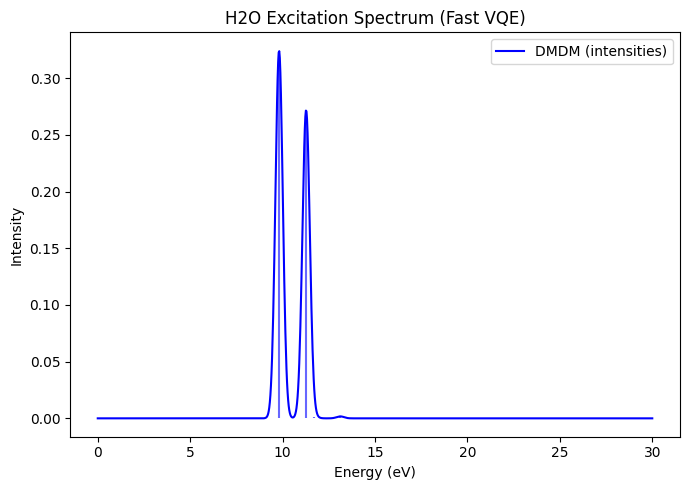

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

hartree_to_ev = 27.2114

# -------------------------
# DMDM results (example)
# -------------------------
# exc_energies_dmdm = dmdm.get_excitation_energies()[:nroots-1] * hartree_to_ev
# osc_strengths = dmdm.get_oscillator_strength(MO_DM)[:nroots-1]

# Prepend 0 eV for ground state
exc_energies_dmdm_aligned = np.concatenate(([0.0], exc_energies_ev[:nroots-1]))
osc_strengths_aligned = np.concatenate(([0.0], osc_strengths[:nroots-1]))


# -------------------------
# Build Gaussian stick spectrum
# -------------------------
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

x = np.linspace(0, 30, 1000)  # energy axis in eV
sigma = 0.2                   # broadening

spectrum_dmdm = np.zeros_like(x)
for e, f in zip(exc_energies_dmdm_aligned, osc_strengths_aligned):
    spectrum_dmdm += f * gaussian(x, e, sigma)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(7,5))

# DMDM stick spectrum
plt.plot(x, spectrum_dmdm, label="DMDM (intensities)", color='blue')

# Optional: plot sticks
# plt.vlines(exc_energies_dmdm_aligned, 0, osc_strengths_aligned, color='blue', alpha=0.6)

# CASCI reference (sticks only)

plt.xlabel("Energy (eV)")
plt.ylabel("Intensity")
plt.title("H2O Excitation Spectrum (Fast VQE)")
plt.legend()
plt.tight_layout()
plt.show()